In [11]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('order_items.csv', 'order_items'),
    ('payments.csv', 'payments'),
    ('geolocation.csv', 'geolocation')
    # Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/milton/Phython/SQL-Python-Projects/datasets'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64



KeyboardInterrupt: 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector
db=mysql.connector.connect(host="localhost",
                          username="root",
                          password="root",
                          database="ecommerce")
cur=db.cursor()

#1.List all unique cities where customers are located.

In [2]:
query=""" select distinct customer_city from customers limit 10  """
cur.execute(query)
data=cur.fetchall()
data

[('franca',),
 ('sao bernardo do campo',),
 ('sao paulo',),
 ('mogi das cruzes',),
 ('campinas',),
 ('jaragua do sul',),
 ('timoteo',),
 ('curitiba',),
 ('belo horizonte',),
 ('montes claros',)]

#2. Count the number of orders placed in 2017.

In [3]:
query="""select count(order_id) from orders where year(order_approved_at)="2017" """
cur.execute(query)
data=cur.fetchall()
data[0][0]

89946

#3. Find the total sales per category.

In [4]:
query="""select product_category,round(sum(payment_value),2) from products 
join order_items on products.product_id=order_items.product_id
join payments on payments.order_id=order_items.order_id
group by product_category """
cur.execute(query)
data=cur.fetchall()
#data
df=pd.DataFrame(data, columns=["Category", "Sales"])
df

,Category,Sales
0,perfumery,1013477.32
1,Furniture Decoration,2860352.78
2,telephony,973764.10
3,bed table bath,3425107.34
4,automotive,1704588.66
...,...,...
69,cds music dvds,2398.86
70,La Cuisine,5827.06
71,Fashion Children's Clothing,1571.34
72,PC Gamer,4348.86


In [5]:
query="""select product_category,round(sum(payment_value),2) from products 
join order_items on products.product_id=order_items.product_id
join payments on payments.order_id=order_items.order_id
group by product_category """
cur.execute(query)
data=cur.fetchall()
#data
df=pd.DataFrame(data, columns=["Category", "Sales"])
df

,Category,Sales
0,perfumery,1013477.32
1,Furniture Decoration,2860352.78
2,telephony,973764.10
3,bed table bath,3425107.34
4,automotive,1704588.66
...,...,...
69,cds music dvds,2398.86
70,La Cuisine,5827.06
71,Fashion Children's Clothing,1571.34
72,PC Gamer,4348.86


#4. Calculate the percentage of orders that were paid in installments.

In [6]:
query="""select (sum(case when payment_installments>=1 then 1 else 0 end))/count(*)*100
from payments """
cur.execute(query)
data=cur.fetchall()
data

[(Decimal('99.9981'),)]

#5. Count the number of customers from each state. 

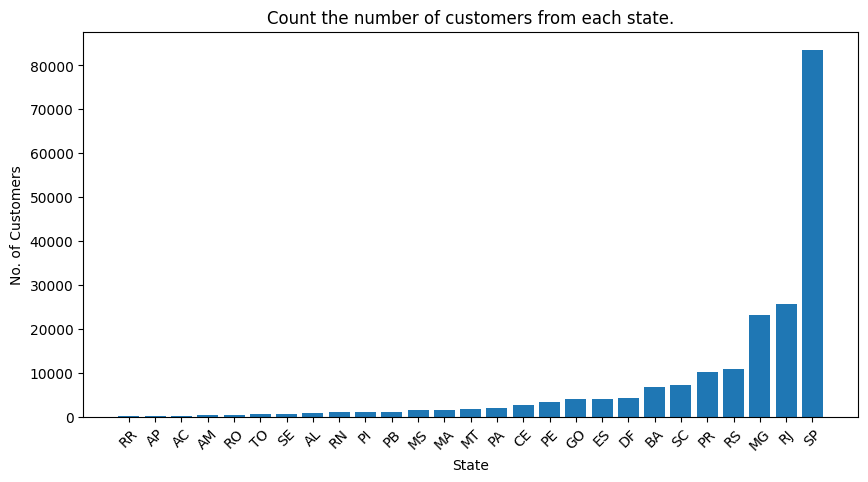

In [7]:
query="""select customer_state,count(customer_id) from customers
group by customer_state """
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data,columns=["State", "count"])
df=df.sort_values(by="count",ascending=True)
plt.figure(figsize=(10,5))
plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("No. of Customers")
plt.title("Count the number of customers from each state.")
#colors=[]
plt.bar(df["State"], df["count"])
plt.show()

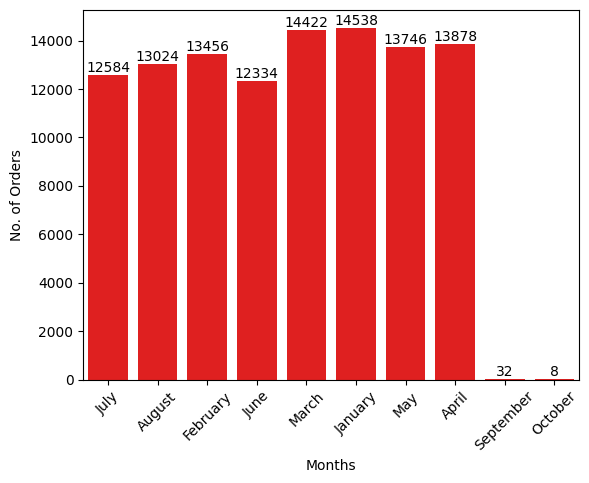

In [8]:
#Intermediate Queries
#6 Calculate the number of orders per month in 2018.
query=""" select monthname(order_purchase_timestamp) months, count(*) order_count from orders 
where year(order_purchase_timestamp)="2018"
group by months 
 """
cur.execute(query)
data=cur.fetchall()
data
df=pd.DataFrame(data, columns=["Months","Count"])
df
ax=sns.barplot(x=df["Months"], y=df["Count"], data=df,color="red")
plt.xticks(rotation=45)
ax.bar_label(ax.containers[0])
plt.xlabel("Months")
plt.ylabel("No. of Orders")
plt.show()


#7 Find the average number of products per order, grouped by customer city.

In [9]:
query=""" #7 Find the average number of products per order, grouped by customer city.

with count_per_order as 
(select orders.order_id,customer_id,count(order_items.order_id) as OC 
from orders 
join order_items on orders.order_id=order_items.order_id
group by orders.order_id,customer_id)

select customers.customer_city,round(avg(count_per_order.OC),2) as count_per_order from customers
join count_per_order on customers.customer_id=count_per_order.customer_id
group by customer_city order by count_per_order desc """

cur.execute(query)
data=cur.fetchall()
data

[('padre carvalho', Decimal('14.00')),
 ('celso ramos', Decimal('13.00')),
 ('datas', Decimal('12.00')),
 ('candido godoi', Decimal('12.00')),
 ('matias olimpio', Decimal('10.00')),
 ('cidelandia', Decimal('8.00')),
 ('curralinho', Decimal('8.00')),
 ('picarra', Decimal('8.00')),
 ('morro de sao paulo', Decimal('8.00')),
 ('teixeira soares', Decimal('8.00')),
 ('inconfidentes', Decimal('7.00')),
 ('ipua', Decimal('6.50')),
 ('alto paraiso de goias', Decimal('6.00')),
 ('nova esperanca do sul', Decimal('6.00')),
 ('capela', Decimal('6.00')),
 ('pedregulho', Decimal('6.00')),
 ('jose boiteux', Decimal('6.00')),
 ('buriti', Decimal('6.00')),
 ('ouvidor', Decimal('6.00')),
 ('pacuja', Decimal('6.00')),
 ('brasileia', Decimal('6.00')),
 ('ubata', Decimal('6.00')),
 ('chapadao do lageado', Decimal('6.00')),
 ('colonia castrolanda', Decimal('5.33')),
 ('ubajara', Decimal('5.33')),
 ('maracana', Decimal('5.00')),
 ('sao miguel dos campos', Decimal('5.00')),
 ('colonia jordaozinho', Decimal('5.

#8. Calculate the percentage of total revenue contributed by each product category.

In [10]:
query="""
select product_category,
round(sum(payment_value)/(select sum(payment_value) from payments)*100,2) as sales_percentage
from products
join order_items on order_items.product_id=products.product_id
join payments on payments.order_id=order_items.order_id
group by product_category order by sales_percentage desc """

cur.execute(query)
data=cur.fetchall()
#data
df=pd.DataFrame(data, columns=["product_category","sales_percentage"])
df

,product_category,sales_percentage
0,bed table bath,21.40
1,HEALTH BEAUTY,20.71
2,computer accessories,19.81
3,Furniture Decoration,17.87
4,Watches present,17.86
...,...,...
69,PC Gamer,0.03
70,House Comfort 2,0.02
71,cds music dvds,0.01
72,Fashion Children's Clothing,0.01


#9. Identify the correlation between product price and the number of times a product has been purchased.

In [11]:
import numpy as np
query="""
select product_category,count(products.product_id) as order_count,round(avg(price),2) as price from products
join order_items on order_items.product_id=products.product_id
group by product_category """

cur.execute(query)
data=cur.fetchall()
#data
df=pd.DataFrame(data, columns=["product_category","order_count","price"])
df
a=np.corrcoef(df["order_count"], df["price"])
print("The correlation between product price and the number of times a product has been purchased ", a[0][1])



The correlation between product price and the number of times a product has been purchased  -0.10631514167157562


#10. Calculate the total revenue generated by each seller, and rank them by revenue.

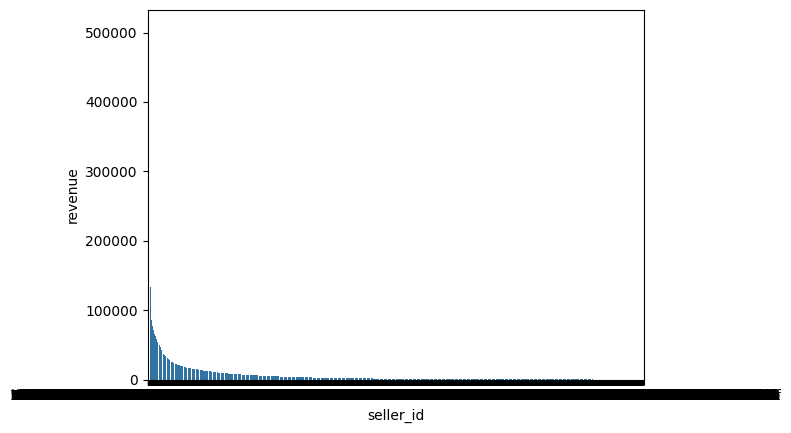

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
query="""
select *,dense_rank() over(order by total_revenue desc) as rn from (select order_items.seller_id as seller_id,round(sum(payment_value),2) as total_revenue
from order_items
join payments on payments.order_id=order_items.order_id
group by seller_id) as a """
# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='ecommerce'
)
cur = conn.cursor()
cur.execute(query)
data=cur.fetchall()
#data

df=pd.DataFrame(data, columns=["seller_id","revenue", "rank"])
df.head(5)
sns.barplot(x=df["seller_id"], y=df["revenue"], data=df)
plt.show()




#11. Calculate the moving average of order values for each customer over their order history.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
query=""" select orders.customer_id as customer_id,orders.order_purchase_timestamp as order_purchase_timestamp
,payments.payment_value as payment_value,
 avg(payment_value) over(partition by customer_id order by order_purchase_timestamp 
rows between UNBOUNDED preceding and current row) as mov_avg 
 from payments
join orders on payments.order_id=orders.order_id """
# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='ecommerce'
)
cur = conn.cursor()
cur.execute(query)
data=cur.fetchall()
#data
df=pd.DataFrame(data, columns=["customer_id","order_purchase_timestamp", "payment_value","mov_avg"])
df.head(5)






,customer_id,order_purchase_timestamp,payment_value,mov_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
3,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
4,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998


#12. Calculate the cumulative sales per month for each year.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
query=""" select years, months,payment,sum(payment) over(order by years, months) as cumulative_sales
 from (select year(order_purchase_timestamp) as years
,month(order_purchase_timestamp) as months 
,round(sum(payment_value), 2) as payment
from orders
join payments on payments.order_id=orders.order_id
group by years,months order by years,months) as a """
# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='ecommerce'
)
cur = conn.cursor()
cur.execute(query)
data=cur.fetchall()
#data
df=pd.DataFrame(data, columns=["years","months", "payment","cumulative_sales"])
df.head(5)


,years,months,payment,cumulative_sales
0,2016,9,504.48,504.48
1,2016,10,118180.96,118685.44
2,2016,12,39.24,118724.68
3,2017,1,276976.08,395700.76
4,2017,2,583816.02,979516.78


#13 Calculate the year-over-year growth rate of total sales.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
query=""" with a as(select year(order_purchase_timestamp) as years,sum(payment_value) as payment from orders
join payments on payments.order_id=orders.order_id
group by years order by years)

select years, ((payment-lag(payment, 1) over(order by years))
/lag(years, 1) over(order by years))*100
from a  """
# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='ecommerce'
)
cur = conn.cursor()
cur.execute(query)
data=cur.fetchall()
#data
df=pd.DataFrame(data, columns=["years","yy % growth"])
df.head(5)


,years,yy % growth
0,2016,NaN
1,2017,713331.784545
2,2018,143779.506558


#14. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
query=""" with a as (select customers.customer_id as customer_id,
min(order_purchase_timestamp) as first_order from orders
join customers on customers.customer_id=orders.customer_id
group by customer_id),

 b as (select a.customer_id,count(distinct orders.order_purchase_timestamp) as next_order from a
join orders on orders.customer_id=a.customer_id
and orders.order_purchase_timestamp> first_order
and  orders.order_purchase_timestamp< date_add(first_order, interval 6 month)
group by a.customer_id)

select 100*(count(distinct a.customer_id)/count(distinct b.customer_id)) from a
left join b on a.customer_id=b.customer_id  """
# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='ecommerce'
)
cur = conn.cursor()
cur.execute(query)
data=cur.fetchall()
data


[(None,)]

#15. Identify the top 3 customers who spent the most money in each year.

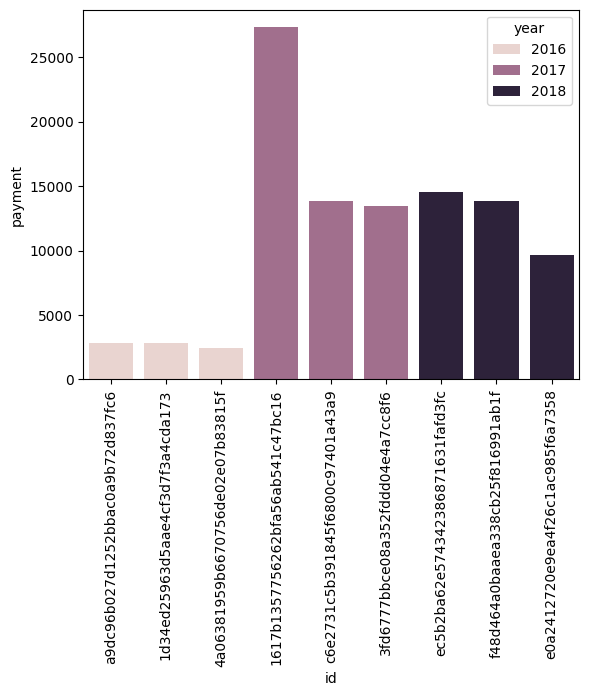

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
query=""" #15. Identify the top 3 customers who spent the most money in each year.

with a as(select orders.customer_id as customer_id
,year(orders.order_purchase_timestamp) as years
,sum(payment_value) as payment
,dense_rank() over(partition by year(orders.order_purchase_timestamp) 
order by sum(payment_value) desc) as d_rank
from orders
join payments on payments.order_id=orders.order_id
group by customer_id,years ) 

select customer_id,years,payment,d_rank from a where d_rank<=3

  """
# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='root',
    database='ecommerce'
)
cur = conn.cursor()
cur.execute(query)
data=cur.fetchall()
df=pd.DataFrame(data, columns=["id","year","payment","rank"])
sns.barplot(x=df["id"], y=df["payment"], data=df, hue="year")
plt.xticks(rotation=90)
plt.show()
